In [ ]:
# DataLab 10-B2 - Relação Risco versus Retorno em Carteiras de InvestimentoAutor
# Autora: Gabriela Alvim De Nigris
# Data: 25/05/2026

In [ ]:
# import das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot

In [ ]:
# nome dos ativos da carteira
vetor_ativos_analisados = ['A', 'B', 'C'] # escolha os seus ativos

# simulação dos ativos a serem analisados
A = np.array([4, 5, 6, 5, 5, 6, 7, 8, 4, 3, 5]) # preço de fechamento do ticker no yahoo finance de 1 mês
B = np.array([1, 5, 10, 4, 11, 7, 8, 3, 1, 5, 7])
C = np.array([3, 4, 3, 4, 5, 6, 5, 4, 5, 3, 4])

# utilizando Pandas para criar o dataframe dos ativos analisados
df = pd.DataFrame([A, B, C], index = vetor_ativos_analisados)
df_precos_ativos = df.T
print(df_precos_ativos)

    A   B  C
0   4   1  3
1   5   5  4
2   6  10  3
3   5   4  4
4   5  11  5
5   6   7  6
6   7   8  5
7   8   3  4
8   4   1  5
9   3   5  3
10  5   7  4


In [ ]:
# cálculo do retorno dos investimentos da carteira
valor_retorno_investimento = df_precos_ativos / df_precos_ativos.shift(1) - 1
print(">> Valor retorno investimento: \n")
print(valor_retorno_investimento)

valor_retorno_medio = valor_retorno_investimento.mean()
print(">> Valor retorno médio: \n")
print(valor_retorno_medio)

# cálculo da covariância da carteira
covariancia_carteira = valor_retorno_investimento.cov()
print(">> Matriz de covariância da carteira: \n")
print(covariancia_carteira)

>> Valor retorno investimento: 

           A         B         C
0        NaN       NaN       NaN
1   0.250000  4.000000  0.333333
2   0.200000  1.000000 -0.250000
3  -0.166667 -0.600000  0.333333
4   0.000000  1.750000  0.250000
5   0.200000 -0.363636  0.200000
6   0.166667  0.142857 -0.166667
7   0.142857 -0.625000 -0.200000
8  -0.500000 -0.666667  0.250000
9  -0.250000  4.000000 -0.400000
10  0.666667  0.400000  0.333333
>> Valor retorno médio: 

A    0.070952
B    0.903755
C    0.068333
dtype: float64
>> Valor da covariância da carteira: 

          A         B         C
A  0.102785  0.013396  0.012241
B  0.013396  3.266941 -0.100178
C  0.012241 -0.100178  0.082435


In [18]:
# distribuição dos pesos de alocação de investimentos
vetor_pesos_investimentos = np.array((0.6, 0.3, 0.1))

# cálculo do retorno e risco da certeira
retorno_investimento = np.sum(vetor_pesos_investimentos * valor_retorno_medio)
print(retorno_investimento)

# calculo do risco do investimento
risco_investimento = np.sqrt(np.dot(vetor_pesos_investimentos.T,
                                    np.dot(covariancia_carteira, vetor_pesos_investimentos)))

# imprime o relatório dos cálculos do Risco x Retorno da carteira de investimentos
print(" # # # # # # # # # # # # # #")
print(f"Retorno esperado da carteira = {str(round(100 * retorno_investimento))} %")
print(f"Risco da carteira = {str(round(100 * risco_investimento, 2))} %")
print("- - - - - - -  - - - - - - - - - -")


0.32053138528138536
 # # # # # # # # # # # # # #
Retorno esperado da carteira = 32 %
Risco da carteira = 57.63 %
- - - - - - -  - - - - - - - - - -


Text(0, 0.5, 'Risco Esperado')

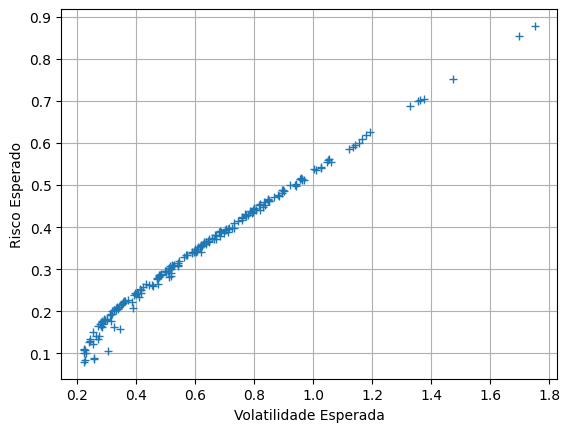

In [28]:
# DataLab 11-B2 - Simulação de Risco Esperado versus Volatilidade Esperada

# construção da simulação de Risco Esperado versus Volatilidade Esperada
vetor_riscos = []
vetor_volatilidade = []

# simular a captura de 200 dias de fechamento do ticker
for i in range(200):
  peso = np.random.random(3) # peso de cada ativo
  peso = peso / np.sum(peso) # soma não passa de 100%
  retorno = np.sum(peso * valor_retorno_medio)
  risco = np.sqrt(np.dot(peso.T, np.dot(covariancia_carteira, peso)))

  # acrescenta aos vetores os valores de riscoe  volatilidade
  vetor_riscos.append(retorno)
  vetor_volatilidade.append(risco)

# plota o gráfico da análise
plot.plot(vetor_volatilidade, vetor_riscos, '+')
plot.grid() # acrescenta grade
plot.xlabel("Volatilidade Esperada")
plot.ylabel("Risco Esperado")